Import các thư viện cần thiết như Numpy và Pandas

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
print(np.__version__)
print(pd.__version__)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) # set up width 


2.3.5
2.3.3


Đọc datasets

In [52]:
df = pd.read_csv("../data/diabetes.csv")
print(df.shape) # Kích thước có 768 bệnh nhân và 9 cột bệnh lý
print('==================================================')
print(df.info()) #Thông tin kiểu dữ liệu của datasets
print('==================================================')


(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Kiểm tra giá trị bất thường

In [53]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

zero_values = (df[cols] == 0).sum()

zero_table = pd.DataFrame({
    "Feature": zero_values.index,
    "Zero Values": zero_values.values,
    "Percentage %": (zero_values / len(df) * 100).round(3)
})

print("Các giá trị 0 bất thường")
display(zero_table)

df[cols] = df[cols].replace(0, np.nan)

Các giá trị 0 bất thường


,Feature,Zero Values,Percentage %
Glucose,Glucose,5,0.651
BloodPressure,BloodPressure,35,4.557
SkinThickness,SkinThickness,227,29.557
Insulin,Insulin,374,48.698
BMI,BMI,11,1.432


Thống kê dữ liệu

In [54]:
eda_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(3).values,
    "Mean": df.mean().round(3).values,
    "Std": df.std().round(3).values,
    "Min": df.min().values,
    "Max": df.max().values
})
print("Bảng thống kê dữ liệu")
display(eda_summary.sort_values('Missing %',ascending=False).reset_index(drop=True))

Bảng thống kê dữ liệu


,Feature,Missing Values,Missing %,Mean,Std,Min,Max
0,Insulin,374,48.698,155.548,118.776,14.000,846.00
1,SkinThickness,227,29.557,29.153,10.477,7.000,99.00
2,BloodPressure,35,4.557,72.405,12.382,24.000,122.00
3,BMI,11,1.432,32.457,6.925,18.200,67.10
4,Glucose,5,0.651,121.687,30.536,44.000,199.00
5,Pregnancies,0,0.000,3.845,3.370,0.000,17.00
6,DiabetesPedigreeFunction,0,0.000,0.472,0.331,0.078,2.42
7,Age,0,0.000,33.241,11.760,21.000,81.00
8,Outcome,0,0.000,0.349,0.477,0.000,1.00


Sau khi kiểm tra dữ liệu, phát hiện ra một số cột chứa giá trị 0 không hợp lý. 
Các giá trị này được coi là missing values và được chuyển thành NaN.

Cột Insulin có tỷ lệ thiếu cao nhất (~48,698%), tiếp theo là cột SkinThickness (~29,557%).
Các cột còn lại có tỷ lệ thiếu thấp (<5%).

BIỂU ĐỒ BIẾN MỤC TIÊU

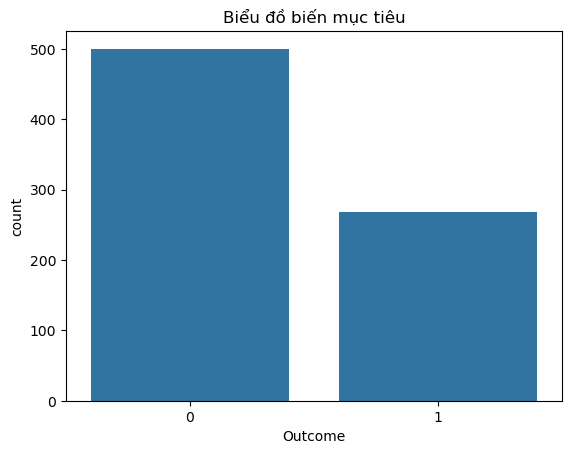

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Outcome', data=df)
plt.title('Biểu đồ biến mục tiêu')

plt.show()

In [56]:

df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [57]:
df['Outcome'].value_counts(normalize = True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

=> Biểu đồ cho thấy số lượng người không mắc tiểu đường( Outcome = 0) nhiều hơn người bị mắc tiểu đường (Outcome = 1). 
Dữ liệu bị mất cân bằng giữa hai lớp.

**Distribution Plots (Histogram, KDE cho numerical features)**

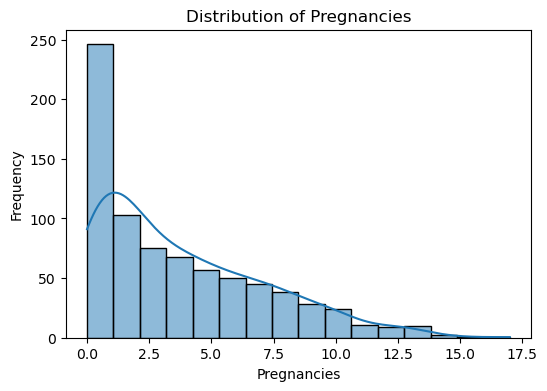

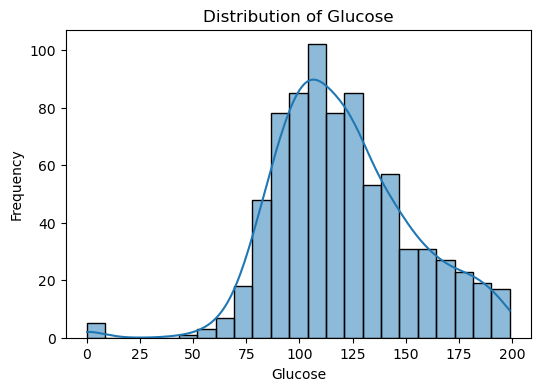

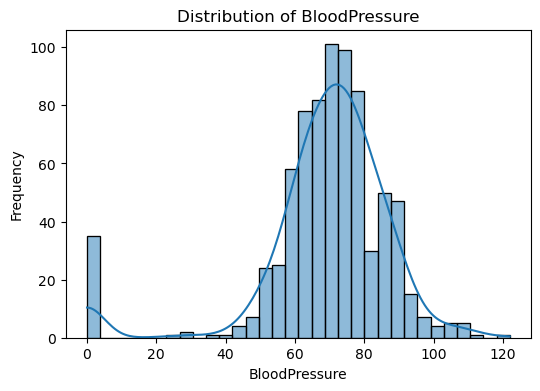

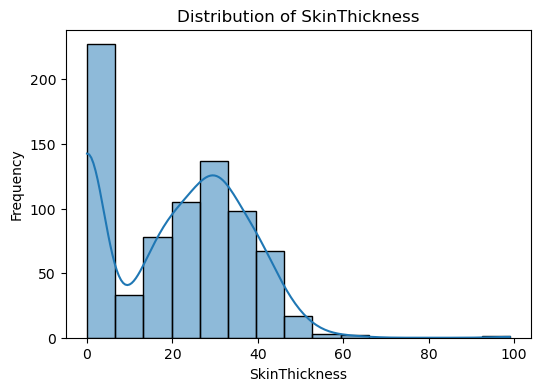

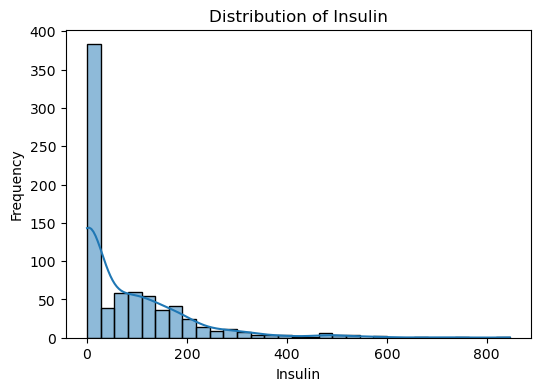

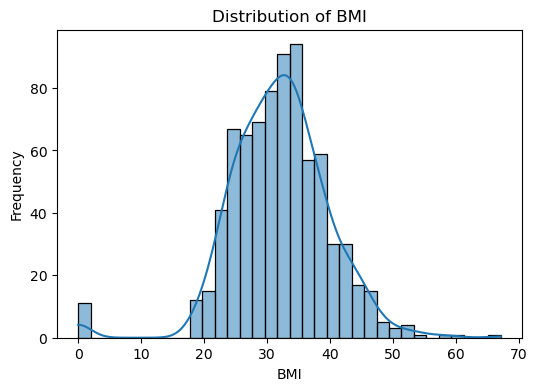

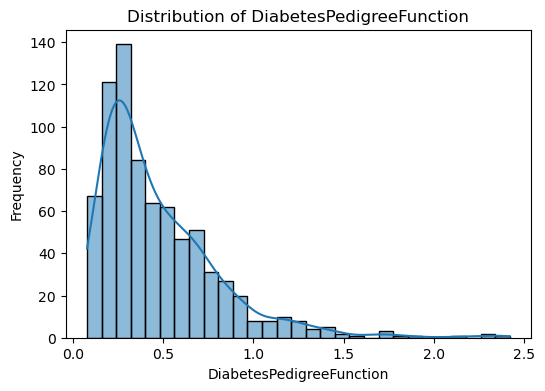

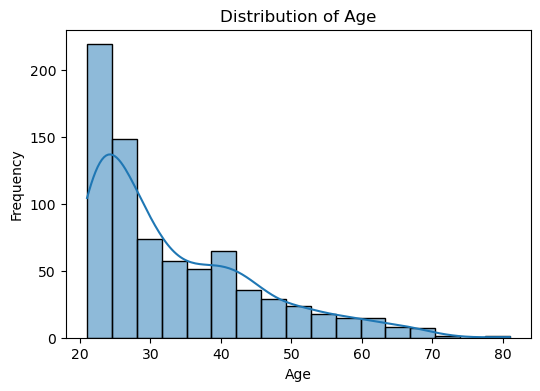

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_raw = pd.read_csv("../data/diabetes.csv")

numerical_features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df_raw[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

CORRELATION HEATMAP

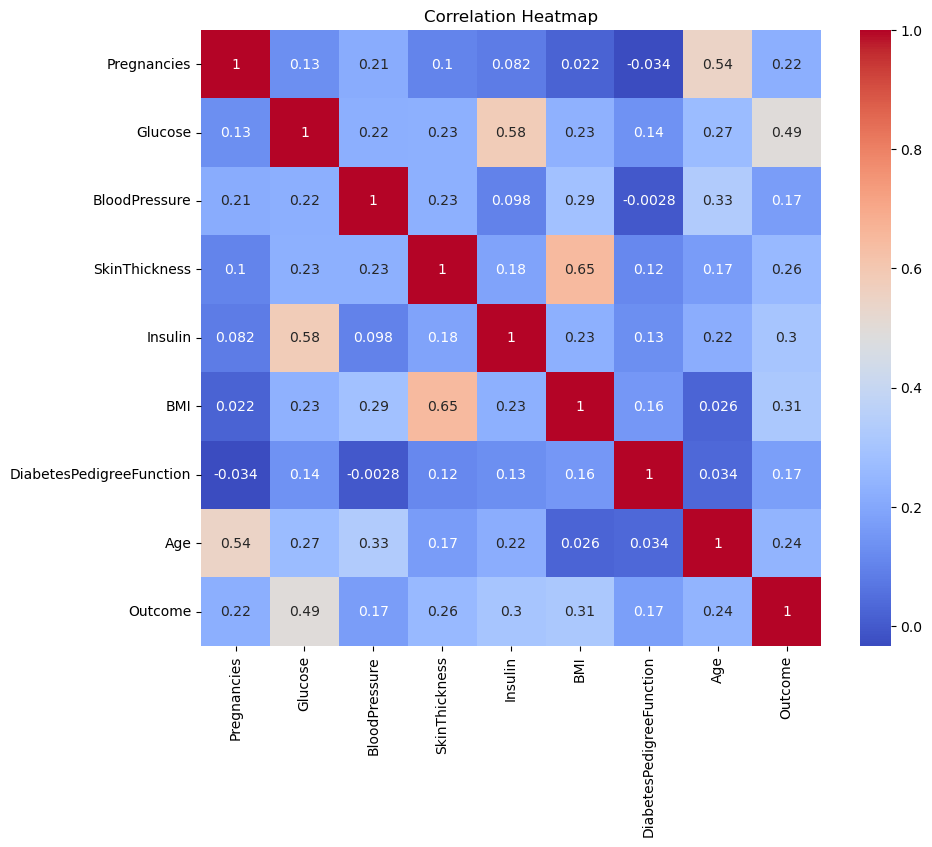

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

=> Biểu đồ correlation heatmap cho thấy mối tương quan giữa các biến trong dataset.
+ "Glucose" có hệ số tương quan cao nhất với "Outcome" là 0.49 -> lượng đường cao dẫn đến khả năng mắc bệnh tiểu đường.

**Categorical Analysis**

**Bar plots**

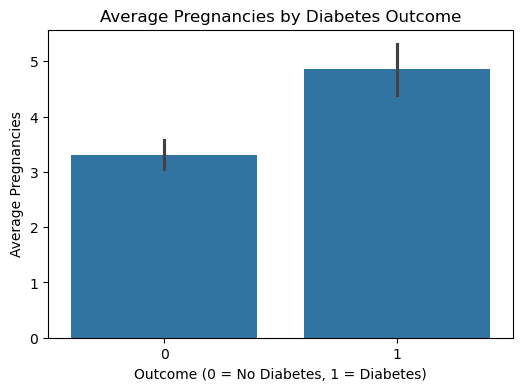

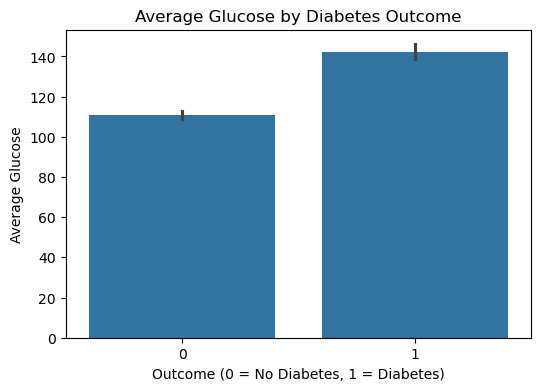

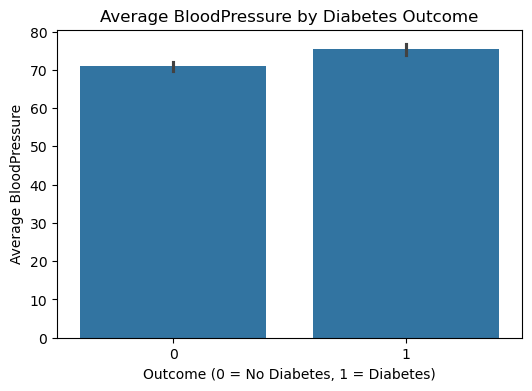

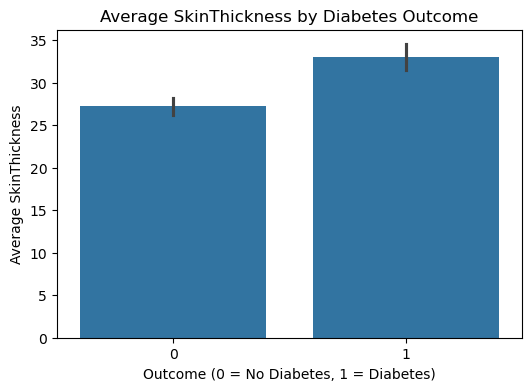

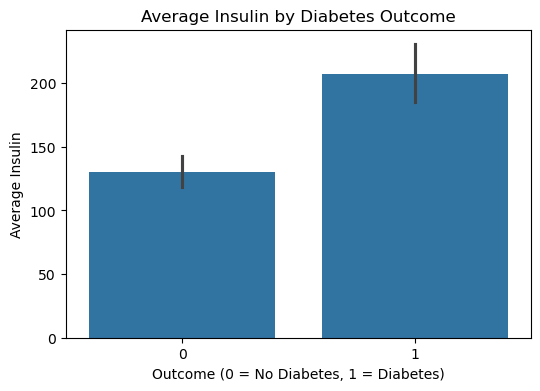

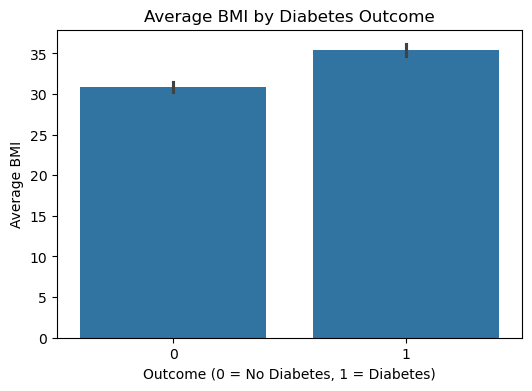

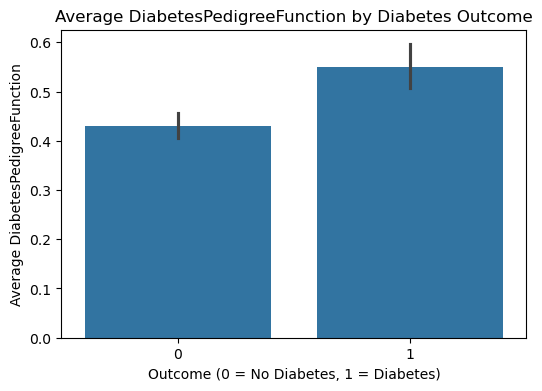

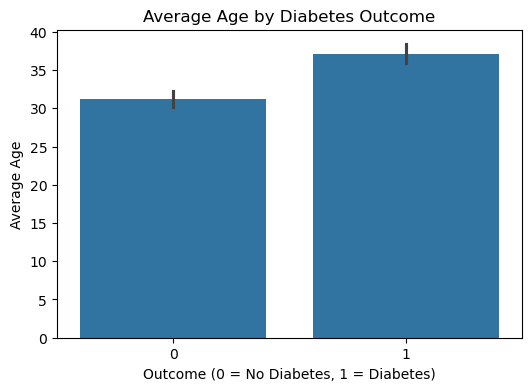

In [60]:
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.barplot(x='Outcome', y=col, data=df)

    plt.title(f'Average {col} by Diabetes Outcome')
    plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
    plt.ylabel(f'Average {col}')

    plt.show()

**Count plots**

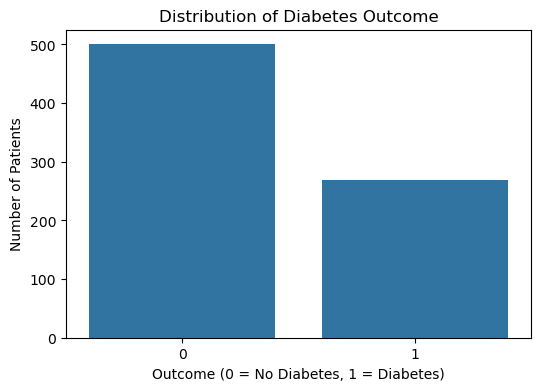

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

PHÂN TÍCH BOXPLOT (PHÁT HIỆN OUTLIERS)

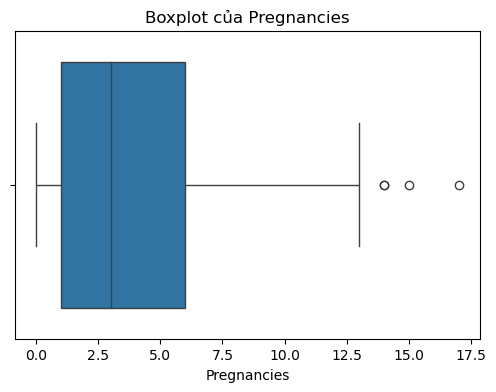

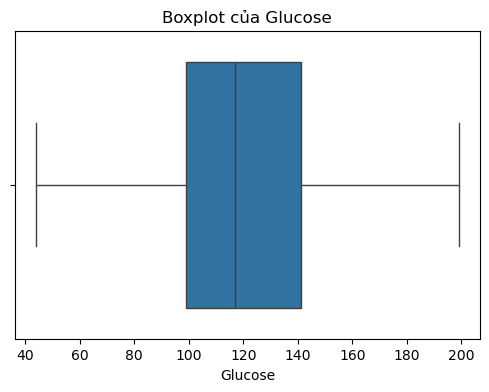

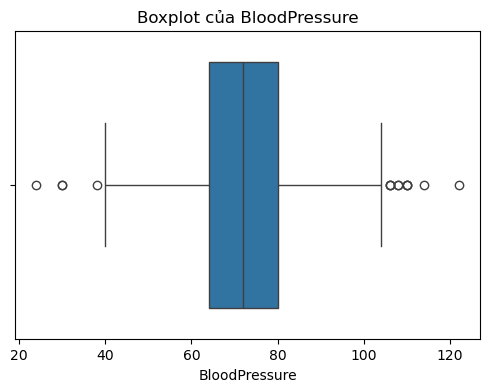

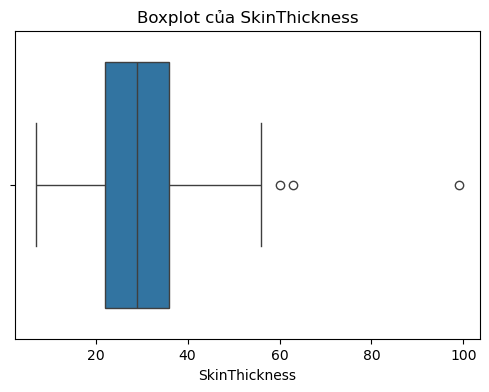

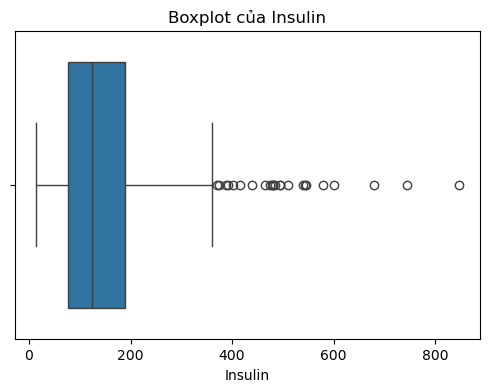

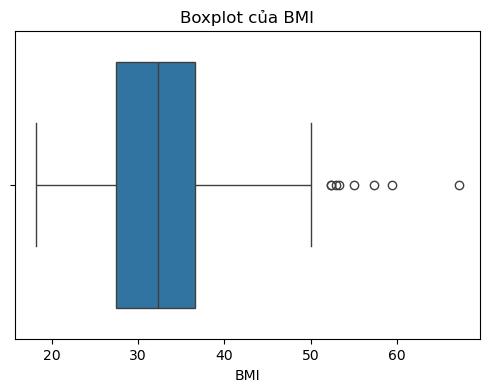

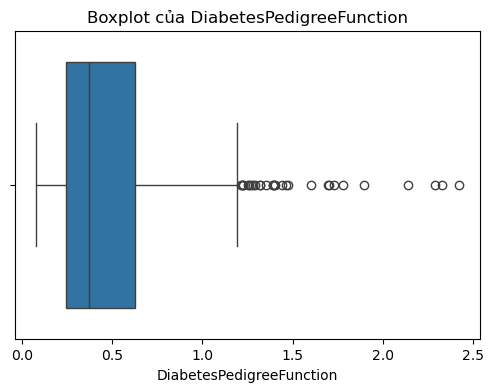

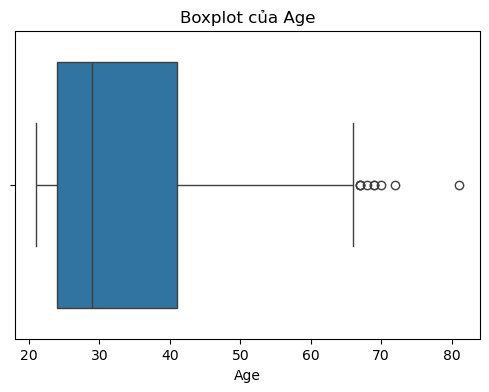

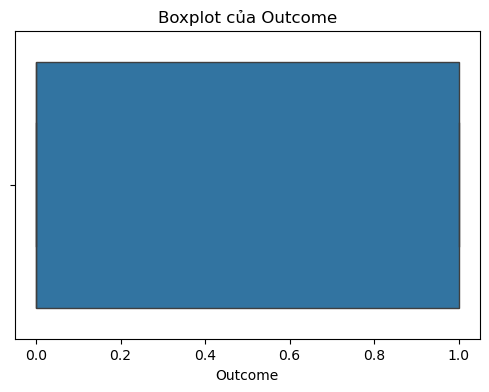

In [62]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot của {col}')
    
    plt.show()

PHÂN TÍCH OUTLIERS BẰNG PHƯƠNG PHÁP IQR

In [63]:
outlier_results = []

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_results)

print('Bảng kết quả phát hiện outliers:')
print(outlier_df)


Bảng kết quả phát hiện outliers:
                    Feature        Q1         Q3       IQR  Lower Bound  Upper Bound  Number of Outliers
0               Pregnancies   1.00000    6.00000    5.0000       -6.500       13.500                   4
1                   Glucose  99.00000  141.00000   42.0000       36.000      204.000                   0
2             BloodPressure  64.00000   80.00000   16.0000       40.000      104.000                  14
3             SkinThickness  22.00000   36.00000   14.0000        1.000       57.000                   3
4                   Insulin  76.25000  190.00000  113.7500      -94.375      360.625                  24
5                       BMI  27.50000   36.60000    9.1000       13.850       50.250                   8
6  DiabetesPedigreeFunction   0.24375    0.62625    0.3825       -0.330        1.200                  29
7                       Age  24.00000   41.00000   17.0000       -1.500       66.500                   9
8                   Ou

KIỂM ĐỊNH THỐNG KÊ T-TEST

In [64]:
from scipy.stats import ttest_ind
ttest_results = []

for col in numeric_cols:
    
    if col != 'Outcome':
        
        group0 = df[df['Outcome'] == 0][col]
        group1 = df[df['Outcome'] == 1][col]
        
        t_stat, p_value = ttest_ind(group0, group1)
        
        ttest_results.append({
            'Feature': col,
            'T-statistic': t_stat,
            'P-value': p_value
        })

ttest_df = pd.DataFrame(ttest_results)

print('Kết quả kiểm định t-test:')
print(ttest_df)

Kết quả kiểm định t-test:
                    Feature  T-statistic       P-value
0               Pregnancies    -6.298431  5.065127e-10
1                   Glucose          NaN           NaN
2             BloodPressure          NaN           NaN
3             SkinThickness          NaN           NaN
4                   Insulin          NaN           NaN
5                       BMI          NaN           NaN
6  DiabetesPedigreeFunction    -4.885826  1.254607e-06
7                       Age    -6.792688  2.209975e-11


NHẬN XÉT KẾT QUẢ KIỂM ĐỊNH

In [65]:
for i,row in ttest_df.iterrows():
    
    if row['P-value'] < 0.05:
        print(f"{row['Feature']} -> Có sự khác biệt, có ý nghĩa thống kê (p = {row['P-value']:.5f})")
    else:
        print(f"{row['Feature']} -> Không có sự khác biệt đáng kể (p = {row['P-value']:.5f})")

Pregnancies -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)
Glucose -> Không có sự khác biệt đáng kể (p = nan)
BloodPressure -> Không có sự khác biệt đáng kể (p = nan)
SkinThickness -> Không có sự khác biệt đáng kể (p = nan)
Insulin -> Không có sự khác biệt đáng kể (p = nan)
BMI -> Không có sự khác biệt đáng kể (p = nan)
DiabetesPedigreeFunction -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)
Age -> Có sự khác biệt, có ý nghĩa thống kê (p = 0.00000)


 KIỂM ĐỊNH CHI-SQUARE 

In [66]:
from scipy.stats import chi2_contingency


df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[20,30,40,50,60,100],
    labels=['20-30','30-40','40-50','50-60','60+']
)

contingency_table = pd.crosstab(df['Age_Group'], df['Outcome'])

print('Bảng chéo Age_Group và Outcome:')
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print('Kết quả kiểm định Chi-Square:')
print('Chi-square statistic:', chi2)
print('P-value:', p)
print('Degrees of freedom:', dof)

print('Bảng giá trị kỳ vọng:')
print(expected)



Bảng chéo Age_Group và Outcome:
Outcome      0   1
Age_Group         
20-30      327  90
30-40       81  76
40-50       49  64
50-60       23  31
60+         20   7
Kết quả kiểm định Chi-Square:
Chi-square statistic: 81.6612857019655
P-value: 7.74411254791731e-17
Degrees of freedom: 4
Bảng giá trị kỳ vọng:
[[271.484375   145.515625  ]
 [102.21354167  54.78645833]
 [ 73.56770833  39.43229167]
 [ 35.15625     18.84375   ]
 [ 17.578125     9.421875  ]]


NHẬN XÉT CHI-SQUARE 

In [67]:
if p < 0.05:
    print('Có mối quan hệ có ý nghĩa thống kê giữa Age_Group và Outcome')
else:
    print('Không có bằng chứng về mối quan hệ giữa Age_Group và Outcome')

Có mối quan hệ có ý nghĩa thống kê giữa Age_Group và Outcome


In [68]:
# Sau khi print kết quả Chi-Square xong:
df.drop(columns=['Age_Group'], inplace=True, errors='ignore')

TRỰC QUAN HÓA DỮ LIỆU

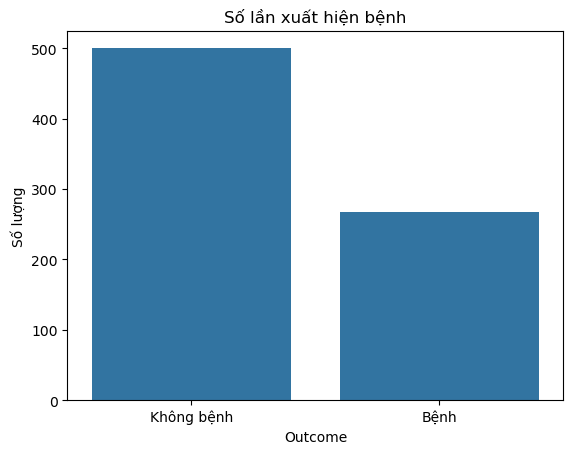

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Outcome', data=df)
plt.xlabel("Outcome")
plt.ylabel("Số lượng")
plt.title('Số lần xuất hiện bệnh')
plt.xticks([0,1], ["Không bệnh","Bệnh"])
plt.show()

=> Biểu đồ cho thấy Dữ liệu bị mất cân bằng

DATA PREPROCESSING + PIPELINE

* KHÔNG CẦN ENCODING vì tất cả dữ liệu trong bảng đã là dạng số.
* SCALING (STANDARDSCALER): giúp đưa dữ liệu về dạng có trung bình (mean) xấp xỉ bằng 0 và độ lệch chuẩn (std) bằng 1 
z = ( x - μ ) / σ
μ : mean
σ : standard deviation
* Dùng Trung vị (Median) thay vì Trung bình (Mean)?
Ít bị ảnh hưởng bởi nhiễu: Nếu dữ liệu có một vài bệnh nhân có chỉ số Insulin cực cao, giá trị Trung bình sẽ bị kéo lên rất cao, nhưng Trung vị thì vẫn đứng yên ở giữa.
An toàn hơn: Trong y tế, các chỉ số thường không phân phối chuẩn hoàn hảo, nên Trung vị phản ánh "người bình thường" tốt hơn.

In [71]:
from imblearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

class OutlierClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.Q1 = np.percentile(X, 25, axis=0)
        self.Q3 = np.percentile(X, 75, axis=0)
        self.IQR = self.Q3 - self.Q1
        return self
    def transform(self, X):
        return np.clip(X, self.Q1 - 1.5 * self.IQR, self.Q3 + 1.5 * self.IQR)

class ZeroToNaN(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X_copy = np.array(X).copy()
        return np.where(X_copy == 0, np.nan, X_copy)

cols_fix_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
cols_keep_zero = ['Pregnancies', 'DiabetesPedigreeFunction', 'Age']
# Tách X và y
X = df.drop('Outcome', axis=1)
y = df['Outcome']

num_cols = X.columns.tolist()

# Train-test split
# chia dữ liệu thành train và test 8:2
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
zero_handler_pipeline = Pipeline([
    ('zero_to_nan', ZeroToNaN()),
    ('imputer', SimpleImputer(strategy='median'))
])

# Gom tất cả vào ColumnTransformer
preprocessor = ColumnTransformer([
    # Nhóm 1: Chuyển 0 -> NaN -> Điền Median
    ('fix_zero', Pipeline([
        ('z2n', ZeroToNaN()),
        ('imp', SimpleImputer(strategy='median'))
    ]), cols_fix_zero),
    
    # Nhóm 2: Giữ nguyên (Pregnancies, Age...)
    ('keep_zero', 'passthrough', cols_keep_zero)
])
# Đếm trước khi SMOTE
print("Trước SMOTE:")
print(y_train.value_counts())

# Preprocessing
num_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    #('zero_to_nan', ZeroToNaN()),
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier', OutlierClipper()),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols)
])

# Pipeline
# SMOTE
model = Pipeline([
    ('prep', preprocessor),      # Xử lý giá trị 0 và điền khuyết
    ('outlier', OutlierClipper()),# Xử lý ngoại lệ cho toàn bộ các cột sau khi đã điền đủ
    ('scaler', StandardScaler()), # Chuẩn hóa
    ('smote', SMOTE(random_state=42)), # Cân bằng dữ liệu
    ('classifier', RandomForestClassifier(random_state=42)) # Mô hình
])

# Train
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)
# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Sau SMOTE:")
X_tmp = preprocessor.fit_transform(X_train)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_tmp, y_train)
print(pd.Series(y_res).value_counts())
print("Accuracy:", acc)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Trước SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64
Sau SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64
Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



1. Không còn giá trị thiếu (Missing Values)
Cột Missing Values đều bằng 0 và Missing % là 0.0 cho thấy tập dữ liệu đã được điền khuyết (Imputed) đầy đủ.

2. Đã xử lý các giá trị 0 "vô lý"
Trong bộ dữ liệu gốc về tiểu đường này, các cột như Glucose, BloodPressure, BMI, Insulin thường có rất nhiều số 0. Các số 0 bất thường được chuyển thành NaN và đã được thay thế bằng trung vị trước khi tiến hành chuẩn hóa.

3. Đã được Chuẩn hóa (Standardized)
Đây là dấu hiệu rõ rệt nhất cho thấy dữ liệu đã qua tiền xử lý để đưa vào mô hình Machine Learning:
* Mean (Trung bình) ≈ 0: Bạn có thể thấy các con số như -0.000, 0.021, 0.006... đều cực kỳ gần bằng 0.
* Std (Độ lệch chuẩn) ≈ 1: Các giá trị như 1.015, 0.993, 1.008... đều xấp xỉ bằng 1.
Dữ liệu hiện đang ở dạng Z-score, giúp các thuật toán (như SVM, KNN, Logistic Regression) không bị lệch do khác biệt về đơn vị đo lường.

4. Đã xử lý ngoại lệ (Outliers)
* Các giá trị Min và Max nằm trong khoảng từ khoảng -2.7 đến +2.9, đảm bảo không gây nhiễu.
* Thông thường, nếu chưa xử lý ngoại lệ, cột Max có thể vọt lên rất cao (ví dụ > 5.0).

  

LƯU DATA ĐÃ LÀM SẠCH THÀNH FILE .CSV

In [72]:
cleaning_steps = Pipeline(model.steps[:-2])
X_cleaned = cleaning_steps.transform(X)
df_final = pd.DataFrame(X_cleaned, columns=cols_fix_zero + cols_keep_zero)
df_final['Outcome'] = y.values
df_final.to_csv('diabetes_cleaned.csv', index=False)

FEATURE ENGINEERING

In [54]:
df = pd.read_csv("../data/diabetes.csv")#Reset lại dữ liệu gốc,Tránh lỗi mất cột do chạy notebook nhiều lần
print("=== Original Columns ===")
print(df.columns.tolist())

=== Original Columns ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [55]:
df["BMI_Category"] = pd.cut(df["BMI"],
                           bins=[0, 18.5, 24.9, 29.9, 100],
                           labels=["Underweight", "Normal", "Overweight", "Obese"])

Giải thích tại sao lại tạo Feature BMI Category
1.BMI là biến liên tục, nhưng trong thực tế y khoa, BMI thường được phân loại thành các nhóm như:
    Gầy (Underweight)
    Bình thường (Normal)
    Thừa cân (Overweight)
    Béo phì (Obese)
2.Việc chuyển BMI thành dạng phân loại giúp mô hình:
    Dễ nhận diện các mức độ rủi ro sức khỏe
    Nắm bắt được các ngưỡng quan trọng (threshold) thay vì chỉ giá trị số
3.Ý nghĩa
    Các nghiên cứu cho thấy người thừa cân và béo phì có nguy cơ mắc bệnh tiểu đường cao hơn, do đó feature này giúp mô hình học tốt hơn về nguy cơ bệnh.

In [56]:
df["Glucose_BMI_Ratio"] = df["Glucose"] / (df["BMI"] + 1e-5)

Giải thích tại sao lại tạo Feature Glucose/BMI Ratio 1.Glucose và BMI là hai yếu tố quan trọng ảnh hưởng đến bệnh tiểu đường. Tuy nhiên, khi xét riêng lẻ, mỗi biến chỉ phản ánh một khía cạnh. 2.Việc tạo tỷ lệ giữa Glucose và BMI giúp: Kết hợp thông tin của hai biến thành một đặc trưng mới Phản ánh mối quan hệ tương đối giữa đường huyết và thể trạng 3.Ý nghĩa Một người có glucose cao nhưng BMI thấp có thể có nguy cơ khác so với người có cùng glucose nhưng BMI cao. Feature này giúp mô hình phân biệt các trường hợp đó tốt hơn.

In [57]:
df["Age_Group"] = pd.cut(df["Age"],
                        bins=[0, 30, 50, 100],
                        labels=["Young", "Middle", "Old"])

Giải thích tại sao lại tạo Feature Age Group
1.Tuổi là biến liên tục, nhưng nguy cơ mắc bệnh thường tăng theo từng giai đoạn tuổi chứ không tăng đều.
2.Việc chia nhóm tuổi giúp:
    Đơn giản hóa dữ liệu
    Làm nổi bật các nhóm có nguy cơ khác nhau
3.Ý nghĩa 
    Người lớn tuổi thường có nguy cơ mắc tiểu đường cao hơn so với người trẻ. Feature này giúp mô hình học được xu hướng theo nhóm tuổi rõ ràng hơn.

PREVIEW FEATURES

In [58]:
print("\n=== Preview Features ===")
print(df[["BMI_Category", "Glucose_BMI_Ratio", "Age_Group"]].head(10))

print("\n=== BMI_Category Distribution ===")
print(df["BMI_Category"].value_counts())

print("\n=== Age_Group Distribution ===")
print(df["Age_Group"].value_counts())

print("\n=== Glucose_BMI_Ratio Stats ===")
print(df["Glucose_BMI_Ratio"].describe())


=== Preview Features ===
  BMI_Category  Glucose_BMI_Ratio Age_Group
0        Obese       4.404761e+00    Middle
1   Overweight       3.195488e+00    Middle
2       Normal       7.854074e+00    Middle
3   Overweight       3.167259e+00     Young
4        Obese       3.178654e+00    Middle
5   Overweight       4.531248e+00     Young
6        Obese       2.516128e+00     Young
7        Obese       3.257789e+00     Young
8        Obese       6.459014e+00       Old
9          NaN       1.250000e+07       Old

=== BMI_Category Distribution ===
BMI_Category
Obese          472
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64

=== Age_Group Distribution ===
Age_Group
Young     417
Middle    270
Old        81
Name: count, dtype: int64

=== Glucose_BMI_Ratio Stats ===
count    7.680000e+02
mean     1.493528e+05
std      1.259901e+06
min      0.000000e+00
25%      3.053626e+00
50%      3.768472e+00
75%      4.623584e+00
max      1.360000e+07
Name: Glucose_BMI_Rat

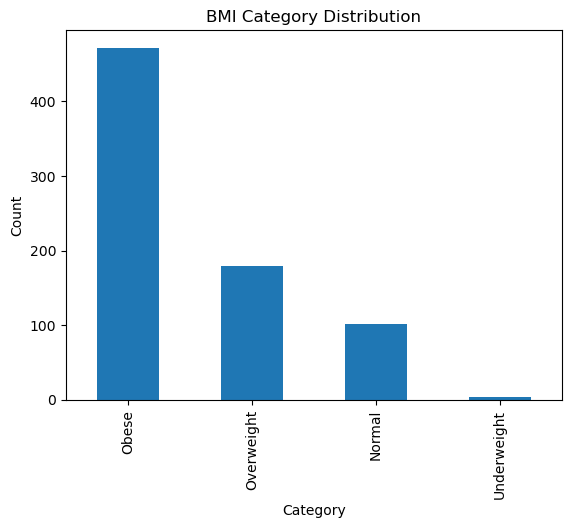

In [59]:
df["BMI_Category"].value_counts().plot(kind="bar")
plt.title("BMI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

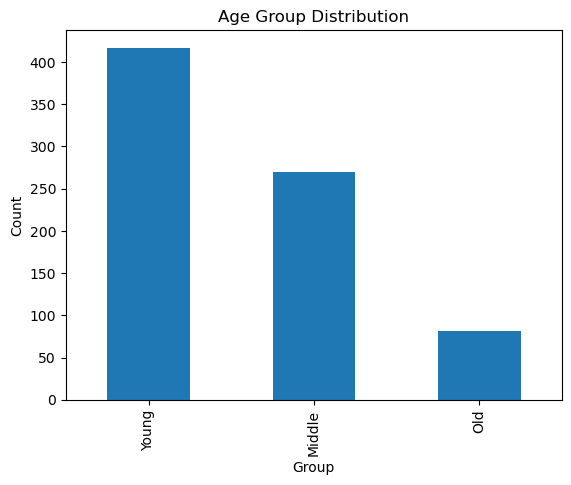

In [60]:
df["Age_Group"].value_counts().plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

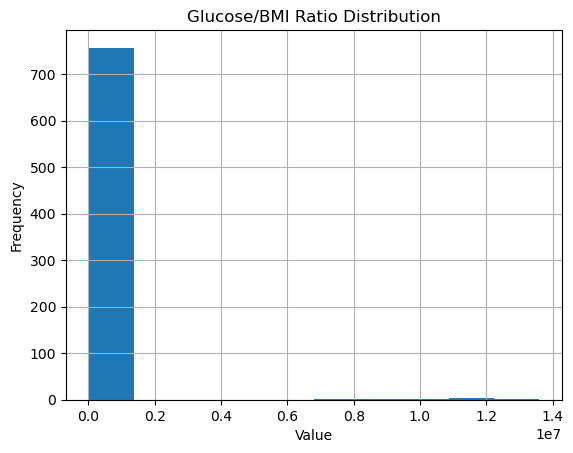

In [61]:
df["Glucose_BMI_Ratio"].hist()
plt.title("Glucose/BMI Ratio Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

Encoding

In [62]:
df = pd.get_dummies(df, columns=["BMI_Category", "Age_Group"], drop_first=True)

print("\n=== Columns AFTER Encoding ===")
print(df.columns.tolist())


=== Columns AFTER Encoding ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_BMI_Ratio', 'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese', 'Age_Group_Middle', 'Age_Group_Old']


In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

X_old = df.drop(["Outcome", "Glucose_BMI_Ratio"], axis=1)
y = df["Outcome"]

rf_model = RandomForestClassifier(random_state=42)
score_old = cross_val_score(rf_model, X_old, y, cv=5).mean()

X_new = df.drop("Outcome", axis=1)
score_new = cross_val_score(rf_model, X_new, y, cv=5).mean()

print("\n=== MODEL EVALUATION ===")
print("Accuracy BEFORE:", score_old)
print("Accuracy AFTER:", score_new)


=== MODEL EVALUATION ===
Accuracy BEFORE: 0.7708938120702827
Accuracy AFTER: 0.7721755368814193


ĐÁNH GIÁ: Tỷ lệ dự đoán đúng của mô hình(Accuracy)
Kết quả đánh giá cho thấy độ chính xác của mô hình tăng từ 0.7669 lên 0.774 sau khi thêm các feature mới. Điều này chứng tỏ các feature được tạo ra có đóng góp tích cực vào việc cải thiện hiệu suất mô hình, mặc dù mức cải thiện còn nhỏ.

FEATURE IMPORTANCE

In [64]:
# Dùng model đã train
importances = model.named_steps['classifier'].feature_importances_

# Lấy tên feature đúng
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Tạo bảng
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10).reset_index(drop=True)

# Bỏ prefix 'num__'
feat_df['Feature'] = feat_df['Feature'].str.replace('num__', '')

print("Top 10 Feature Importance")
print(feat_df)

print({len(feature_names)})
print(feature_names)

Top 10 Feature Importance
                    Feature  Importance
0                   Glucose    0.266508
1                       BMI    0.172695
2                       Age    0.123036
3  DiabetesPedigreeFunction    0.114480
4                   Insulin    0.089847
5               Pregnancies    0.079896
6             BloodPressure    0.078838
7             SkinThickness    0.074701
{8}
['num__Pregnancies' 'num__Glucose' 'num__BloodPressure'
 'num__SkinThickness' 'num__Insulin' 'num__BMI'
 'num__DiabetesPedigreeFunction' 'num__Age']


In [65]:
# 1. Tạo lại X, y từ df cuối cùng (sau feature engineering)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# 2. Split dữ liệu (QUAN TRỌNG)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. SMOTE (chỉ trên train)
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

# 4. Scaling (nếu bạn đang dùng StandardScaler)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Train lại model
model.fit(X_train, y_train)

ValueError: Specifying the columns using strings is only supported for dataframes.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.7727272727272727
Precision: 0.6557377049180327
Recall   : 0.7407407407407407
F1-score : 0.6956521739130435


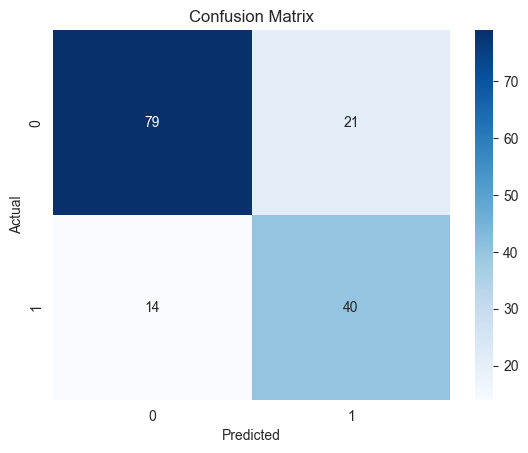

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

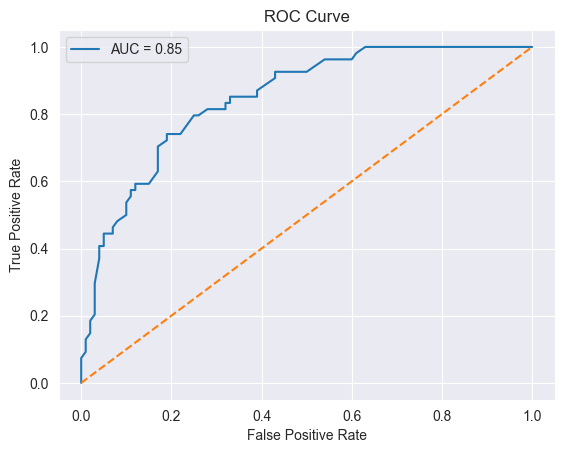

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

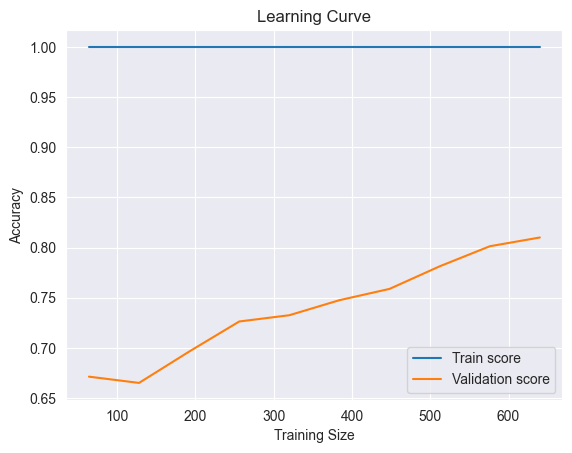

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

# X_train đã qua SMOTE
# Learning curve phản ánh performance trên tập đã xử lý, không phải dữ liệu gốc
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Train score")
plt.plot(train_sizes, val_mean, label="Validation score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

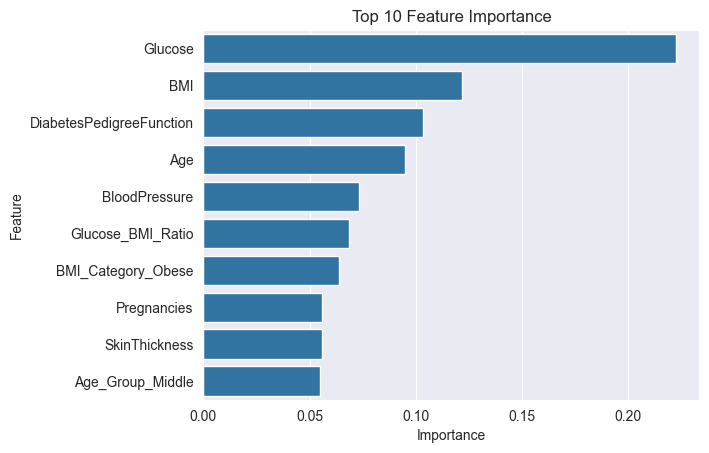

                     Feature  Importance
1                    Glucose    0.222315
5                        BMI    0.121781
6   DiabetesPedigreeFunction    0.103543
7                        Age    0.094822
2              BloodPressure    0.073343
8          Glucose_BMI_Ratio    0.068295
11        BMI_Category_Obese    0.063709
0                Pregnancies    0.056027
3              SkinThickness    0.055616
12          Age_Group_Middle    0.054964


In [ ]:
import pandas as pd

importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Top 10 Feature Importance")
plt.show()

print(feat_df)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.766234   0.650000  0.722222  0.684211
1        Decision Tree  0.707792   0.588235  0.555556  0.571429
2        Random Forest  0.746753   0.631579  0.666667  0.648649


Random Forest đạt hiệu suất tốt nhất với độ chính xác (Accuracy) cao nhất (0.772) và F1-score cao nhất (0.69).
Mô hình duy trì sự cân bằng tốt giữa Precision và Recall, nên phù hợp cho bài toán dự đoán bệnh tiểu đường.
Logistic Regression cũng cho kết quả khá ổn định, trong khi Decision Tree thể hiện khả năng tổng quát hóa kém.